<div dir="rtl">

# זיהוי משטרי שוק באמצעות Gaussian HMM

## פרויקט גמר בקורס "שיטות מתקדמות בלמידת מכונה"

**מתן אשל, 203502802**

המחקר בוחן שתי שאלות נפרדות אך קשורות: האם `Gaussian HMM` מסייע בחיזוי כיוון התשואה ביום הבא, והאם הוא מצליח לגלות **מבנה לטנטי יציב ומשמעותי של משטרי שוק**. ההבחנה חשובה: מודל יכול להיות שימושי לתיאור מצב השוק גם אם אינו מנבא באופן עקבי את היום הבא.

הגרסה הסופית כוללת תשעה נכסים מייצגים: `SPY`, `QQQ`, `IWM`, `TLT`, `GLD`, `HYG`, `BTC-USD`, `JPM`, `NVDA`. בנוסף ל-HMM עם \(K\in\{2,3,4\}\), נבדקים Baselines פשוטים ומודלי Supervised ML (`Logistic Regression`, `Random Forest`, `HistGradientBoosting`). המחברת קוראת את תוצרי הריצות המאומתות ואינה מקשיחה מאות מספרים בתוך התאים.

</div>

<div dir="rtl">

## 1. תצורת המחקר ומקורות התוצאות

שתי ריצות משמשות בסיס לניתוח הסופי:

- `extended_20260811_121957` — HMM מורחב, posterior uncertainty, seed stability, walk-forward, VIX ו-cross-asset analysis.
- `supervised_20260811_133344` — Logistic Regression, Random Forest ו-HistGradientBoosting על אותם Features ואותו split.

הנתונים התבקשו לטווח `2014-01-01` עד `2024-12-31`. זהו חלון הבקשה המשותף; זמינות התצפיות בפועל שונה מעט בין נכסים, ובפרט `BTC-USD` מתחיל מאוחר יותר. כל split מחושב מתוך התצפיות הזמינות בפועל לכל נכס. החלוקה כרונולוגית: כ-70% Train, כ-15% Validation וכ-15% Test, ושורות גבול שבהן יעד היום הבא חוצה partition הוסרו. בשלב בחירת ה-HMM ה-scaler מותאם על Train בלבד; לאחר נעילת K וה-seed מתבצע refit של ה-HMM וה-scaler על Train+Validation לפני ההערכה על Test. מודלי ה-Supervised הקבועים מאומנים על Train בלבד.

</div>

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd().resolve()
EXTENDED_RUN = PROJECT_ROOT / "experiments_extended" / "extended_20260811_121957"
SUPERVISED_RUN = PROJECT_ROOT / "experiments_supervised" / "supervised_20260811_133344"

assert (PROJECT_ROOT / "src").is_dir(), "יש להריץ את המחברת משורש הפרויקט."
assert EXTENDED_RUN.is_dir(), f"חסרה תיקיית HMM: {EXTENDED_RUN}"
assert SUPERVISED_RUN.is_dir(), f"חסרה תיקיית supervised: {SUPERVISED_RUN}"

with (EXTENDED_RUN / "manifest.json").open(encoding="utf-8") as f:
    hmm_manifest = json.load(f)
with (SUPERVISED_RUN / "manifest.json").open(encoding="utf-8") as f:
    supervised_manifest = json.load(f)

assert hmm_manifest["status"] == "completed"
assert supervised_manifest["status"] == "completed"
assert hmm_manifest["data_load_failures"] == []
assert supervised_manifest["data_load_failures"] == []

ASSETS = hmm_manifest["config"]["assets"]
FEATURES = hmm_manifest["config"]["feature_cols"]

print("HMM run:", hmm_manifest["run_id"])
print("Supervised run:", supervised_manifest["run_id"])
print("Assets:", ", ".join(ASSETS))
print("Features:", ", ".join(FEATURES))
print("Python:", hmm_manifest["package_versions"]["python"])

HMM run: extended_20260811_121957
Supervised run: supervised_20260811_133344
Assets: SPY, QQQ, IWM, TLT, GLD, HYG, BTC-USD, JPM, NVDA
Features: log_return, rolling_volatility_20, daily_range, volume_change
Python: 3.11.15


<div dir="rtl">

הבדיקות בתא אינן קוסמטיות: הן מוודאות שהמחברת נשענת על ריצות שסומנו `completed`, שכל הנכסים נטענו ושאין כשלי דאטה שקטים. הפאנל נבחר כדי לייצג התנהגויות כלכליות שונות ולא כדי לבחור בדיעבד מניות שמציגות תוצאה יפה.

`SPY` מייצג שוק מניות רחב, `QQQ` צמיחה/טכנולוגיה, `IWM` small caps, `TLT` אג"ח ארוכות, `GLD` זהב, `HYG` אשראי high-yield, `BTC-USD` נכס אלטרנטיבי תנודתי, ו-`JPM` ו-`NVDA` מייצגות פיננסים ומניית growth/high-beta.

</div>

<div dir="rtl">

## 2. Feature Vector ומניעת leakage

לכל יום נבנה וקטור:

\[
x_t=[r_t,\sigma_t^{(20)},\mathrm{Range}_t,\Delta\log V_t]
\]

כאשר \(r_t=\log(P_t/P_{t-1})\), התנודתיות מחושבת על 20 ימי עבר, ה-daily range מתאר את הטווח התוך-יומי, ו-volume change מתאר שינוי לוגריתמי בנפח. אלה ארבעה היבטים פשוטים של מצב השוק: כיוון, volatility, range ופעילות.

</div>

In [2]:
qa = pd.DataFrame(supervised_manifest["qa"])
assert qa["target_safe_split"].all()
assert (~qa["shuffle_used"]).all()
assert (qa["scaler_fit_partition"] == "train").all()
assert (~qa["test_used_for_model_selection"]).all()

protocol = pd.DataFrame({
    "פרט": ["טווח נתונים", "חלוקה", "Features", "K", "Seeds", "Covariance", "בחירה", "Shuffle", "Scaling"],
    "ערך": [
        f'{hmm_manifest["config"]["start_date"]} — {hmm_manifest["config"]["end_date"]}',
        "כ-70% Train / 15% Validation / 15% Test, כרונולוגי",
        ", ".join(FEATURES),
        str(hmm_manifest["config"]["k_values"]),
        str(hmm_manifest["config"]["seeds"]),
        hmm_manifest["config"]["covariance_type"],
        "Validation log-likelihood בלבד",
        "לא",
        "Train בבחירת HMM; Train+Validation ב-refit HMM; Train בלבד ב-Supervised",
    ],
})
display(protocol)

,פרט,ערך
0,טווח נתונים,2014-01-01 — 2024-12-31
1,חלוקה,"כ-70% Train / 15% Validation / 15% Test, כרונו..."
2,Features,"log_return, rolling_volatility_20, daily_range..."
3,K,"[2, 3, 4]"
4,Seeds,"[42, 123, 456, 789, 2026]"
5,Covariance,full
6,בחירה,Validation log-likelihood בלבד
7,Shuffle,לא
8,Scaling,Train בבחירת HMM; Train+Validation ב-refit HMM...


<div dir="rtl">

ה-assertions בתא מתייחסים לריצת ה-Supervised: אין shuffle, ה-scaler של Logistic Regression מותאם על Train בלבד, ו-Test אינו משמש model selection. ב-HMM נשמר אותו עיקרון בזמן בחירת המועמדים, אך לאחר בחירת K וה-seed המודל הסופי עובר refit על Train+Validation. לכן Test נשאר נעול בשני המסלולים, אך כמות ה-pre-Test data ששימשה להתאמה הסופית אינה זהה לחלוטין.

</div>

<div dir="rtl">

## 3. Gaussian HMM בקצרה

ה-state החבוי \(S_t\) מתפתח לפי הנחת Markov מסדר ראשון:

\[
P(S_t\mid S_{1:t-1})=P(S_t\mid S_{t-1})
\]

ומטריצת המעבר מכילה \(a_{ij}=P(S_t=j\mid S_{t-1}=i)\). ב-Gaussian HMM:

\[
X_t\mid S_t=k\sim\mathcal{N}(\mu_k,\Sigma_k)
\]

הפרמטרים נלמדים באמצעות Baum-Welch / EM. לכל נכס נבדקו \(K=2,3,4\) וחמישה seeds, והבחירה נעשתה לפי Validation log-likelihood בלבד.

בנוסף ל-hard state נבדק soft posterior. בהערכת Test ה-inference הוא past-only: עבור יום \(t\) משתמשים ב-\(P(S_t=k\mid X_{1:t})\), ללא תצפיות עתידיות מתוך ה-Test. כך יום שבו המודל מתלבט בין שני states אינו מטופל כאילו הוא שייך בוודאות ל-state יחיד, ובמקביל נשמרת סיבתיות התחזית ליום הבא.

</div>

<div dir="rtl">

## 4. בחירת K ויציבות בין seeds

Likelihood טוב אינו מספיק: מודל יכול להוסיף states ולהיות רגיש ל-initialization. לכן נבדקה גם יציבות חלוקת הימים באמצעות `Adjusted Rand Index (ARI)`. ARI קרוב ל-1 פירושו שריצות שונות מייצרות כמעט אותה חלוקה, ללא תלות במספור שרירותי של ה-labels.

</div>

,asset,selected_k,selected_seed,mean_pairwise_ARI,min_pairwise_ARI,min_state_occupancy_across_seeds_pct
0,SPY,4,456,0.995,0.992,4.060
1,QQQ,4,2026,0.960,0.902,3.436
2,IWM,4,456,0.819,0.593,1.978
3,TLT,3,2026,1.000,1.000,2.447
4,GLD,4,789,0.681,0.469,13.378
5,HYG,4,789,0.975,0.938,0.260
6,BTC-USD,4,2026,0.553,0.406,11.400
7,JPM,4,42,0.934,0.890,7.652
8,NVDA,4,789,0.984,0.973,10.724


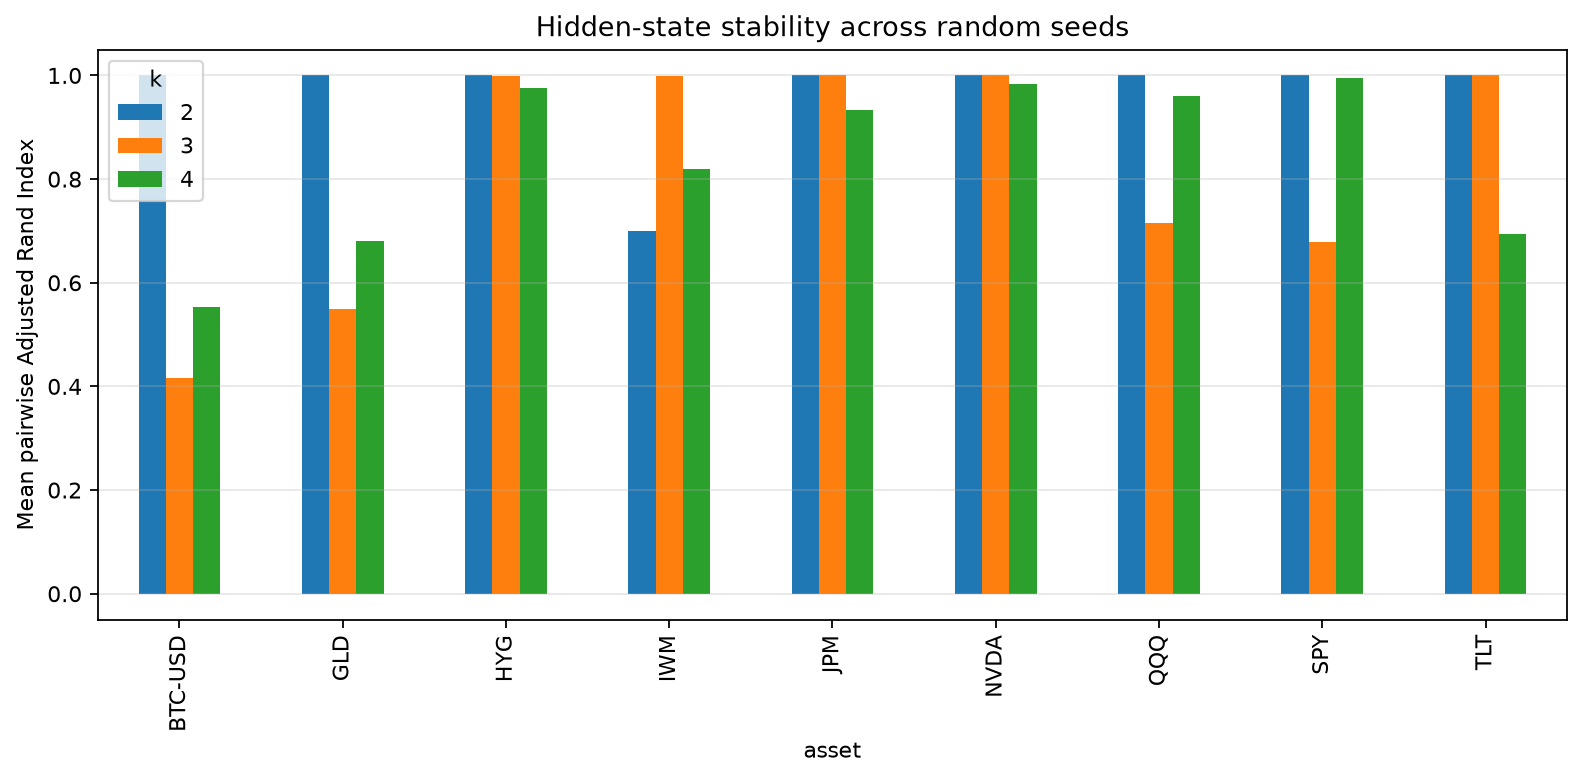

In [3]:
asset_status = pd.DataFrame(hmm_manifest["asset_status"])[
    ["asset", "selected_k", "selected_seed", "test_start", "test_end"]
].copy()
seed_stability = pd.read_csv(EXTENDED_RUN / "seed_stability_all_assets.csv")
selected_stability = asset_status.merge(
    seed_stability,
    left_on=["asset", "selected_k"],
    right_on=["asset", "k"],
    how="left",
)[["asset", "selected_k", "selected_seed", "mean_pairwise_ARI", "min_pairwise_ARI", "min_state_occupancy_across_seeds_pct"]]
display(selected_stability.round(3))
display(Image(filename=str(EXTENDED_RUN / "seed_stability_ari.png")))

<div dir="rtl">

ב-SPY מתקבל ARI ממוצע של כ-0.995 עבור \(K=4\), ב-QQQ כ-0.960 וב-NVDA כ-0.984. לעומת זאת BTC-USD ו-GLD יציבים פחות ב-\(K=4\). הממצא מחדד trade-off בין expressiveness לבין robustness: יותר states יכולים לתאר מבנה עשיר יותר, אבל לא בכל נכס המבנה העשיר יציב באותה מידה.

</div>

<div dir="rtl">

### בדיקה מפורשת של K=2,3,4 ב-SPY

כדי לראות שהבחירה ב-\(K=4\) אינה רק label בדיעבד, נציג את המועמד בעל Validation log-likelihood הטוב ביותר עבור כל \(K\). `Val. LL / obs.` גבוה יותר (פחות שלילי) עדיף, ואילו BIC נמוך יותר עדיף. `Min occupancy` מזכיר שגם מודל עם likelihood טוב יכול ליצור state קטן מאוד.

</div>

In [4]:
spy_candidates = pd.read_csv(EXTENDED_RUN / "SPY" / "candidate_diagnostics.csv")
best_idx = spy_candidates.groupby("k")["validation_log_likelihood_per_observation"].idxmax()
spy_k_compare = spy_candidates.loc[best_idx, [
    "k", "seed", "validation_log_likelihood_per_observation",
    "aic_train", "bic_train", "min_state_occupancy_pct", "fit_time_sec",
]].sort_values("k").copy()
spy_k_compare = spy_k_compare.rename(columns={
    "validation_log_likelihood_per_observation": "Val. LL / obs.",
    "aic_train": "AIC (Train)",
    "bic_train": "BIC (Train)",
    "min_state_occupancy_pct": "Min occupancy %",
    "fit_time_sec": "Fit time sec",
})
display(spy_k_compare.round(3))

with (EXTENDED_RUN / "SPY" / "selected_model_summary.json").open(encoding="utf-8") as f:
    spy_selected = json.load(f)
print(
    f"Final SPY refit: K={spy_selected['selected_k']}, seed={spy_selected['selected_seed']}, "
    f"converged={spy_selected['final_fit_converged']}, "
    f"iterations={spy_selected['final_fit_iterations']}, "
    f"fit_time={spy_selected['final_fit_time_sec']:.2f}s"
)

,k,seed,Val. LL / obs.,AIC (Train),BIC (Train),Min occupancy %,Fit time sec
3,2,789,-5.206,14763.266,14935.644,30.193,0.498
6,3,123,-4.759,13137.080,13415.110,4.164,0.253
12,4,456,-4.626,11754.021,12148.824,4.060,1.214


Final SPY refit: K=4, seed=456, converged=True, iterations=125, fit_time=0.79s


<div dir="rtl">

ב-SPY Validation likelihood, AIC ו-BIC מציגים אותו סדר העדפה ומעדיפים את \(K=4\). עם זאת, ב-\(K=3\) וב-\(K=4\) קיים state קטן של כ-4% מה-Train, ולכן ממשיכים לבדוק seed stability ואת מאפייני ה-states לפני שמייחסים להם משמעות כלכלית.

</div>

<div dir="rtl">

## 5. SPY כמקרה מבחן: מה מאפיין כל Hidden State?

אין משמעות מובנית למספרי states. לכן השמות ניתנים רק לאחר בדיקת return, volatility, range, drawdown, occupancy ו-dwell time.

</div>

,state,interpretation,frequency_%,mean_daily_return_%,volatility_daily_%,mean_daily_range_%,mean_drawdown_%,worst_drawdown_%,avg_duration_days,mean_posterior_confidence
0,0,Normal / moderate volatility,34.305,0.053,0.692,0.841,-1.721,-13.653,25.000,0.964
1,1,Calm / low volatility,25.000,0.092,0.415,0.586,-0.422,-4.330,32.389,0.986
2,2,Rare stress / crisis-like,4.460,-0.265,3.409,3.614,-15.277,-33.717,8.000,0.973
3,3,Persistent high volatility,36.235,0.039,1.239,1.497,-8.108,-24.496,35.208,0.981


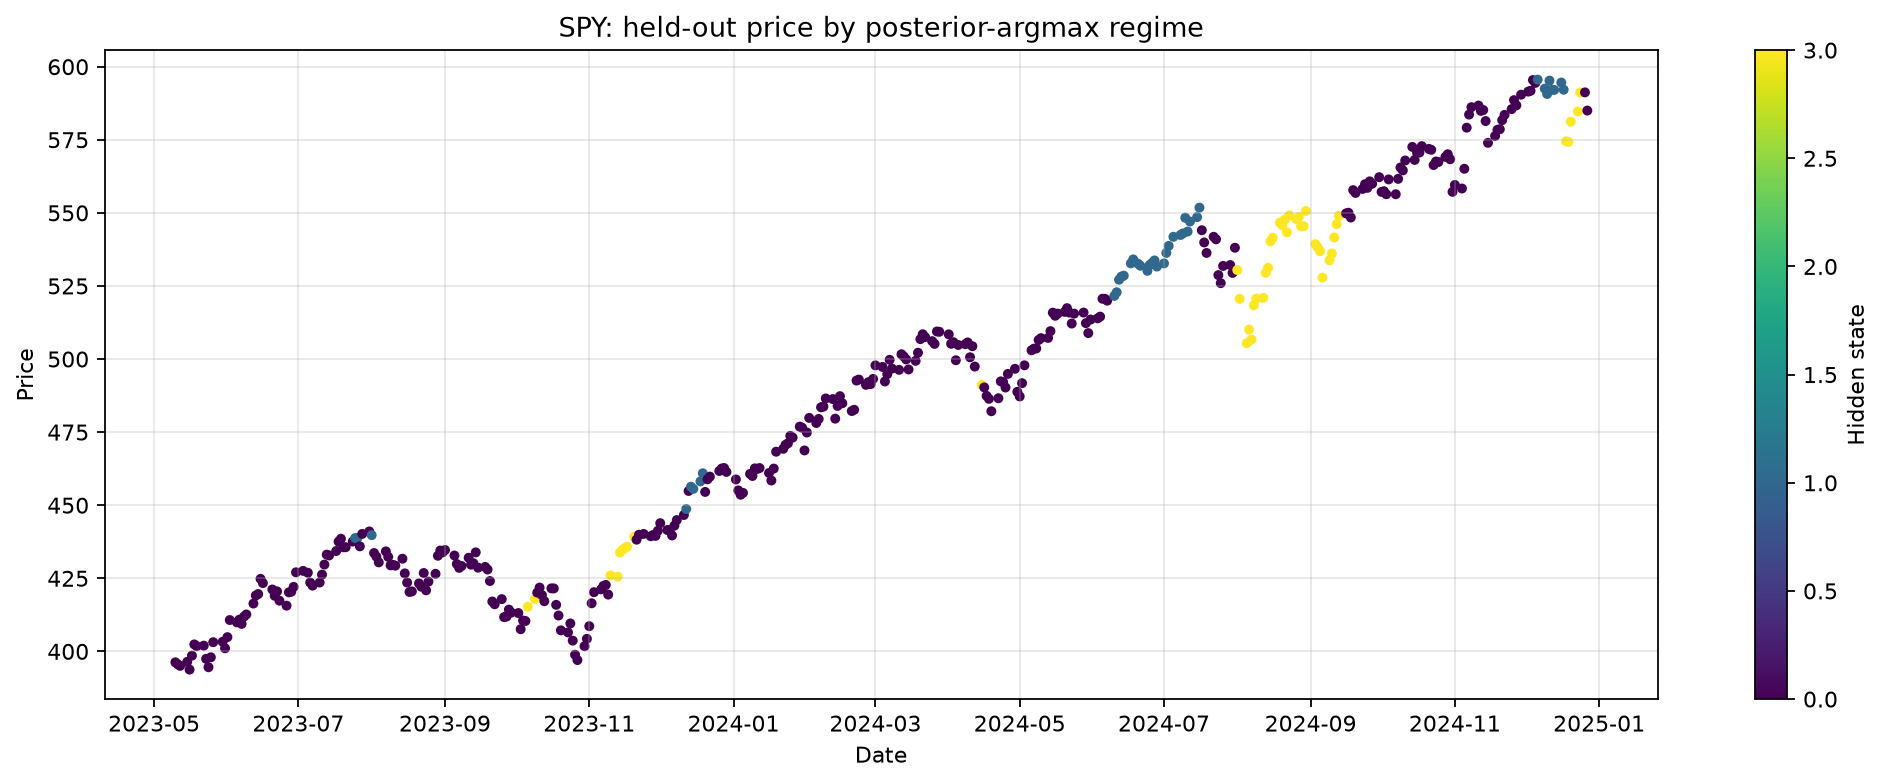

In [5]:
spy_states = pd.read_csv(EXTENDED_RUN / "SPY" / "state_summary_history.csv")
state_labels = {
    0: "Normal / moderate volatility",
    1: "Calm / low volatility",
    2: "Rare stress / crisis-like",
    3: "Persistent high volatility",
}
spy_states["interpretation"] = spy_states["state"].map(state_labels)
cols = [
    "state", "interpretation", "frequency_%", "mean_daily_return_%",
    "volatility_daily_%", "mean_daily_range_%", "mean_drawdown_%",
    "worst_drawdown_%", "avg_duration_days", "mean_posterior_confidence",
]
display(spy_states[cols].round(3))
display(Image(filename=str(EXTENDED_RUN / "SPY" / "test_price_by_regime.png")))

<div dir="rtl">

ההפרדה חזקה במיוחד ב-SPY. State 1 הוא שקט יחסית: volatility יומית של כ-0.42% ומשך ממוצע של כ-32 ימים. State 2 נדיר — כ-4.5% מההיסטוריה — אך בעל תשואה יומית ממוצעת שלילית, volatility של כ-3.41%, daily range של כ-3.61% ו-mean drawdown של כ-15%-.

לכן `crisis-like` הוא label תיאורי post-hoc הנתמך בסטטיסטיקה; הוא אינו ground truth שהוזן למודל. התנהגות ה-volume מפרידה פחות בבירור: mean log-volume change הוא בקירוב 0.21%, 0.00%, 2.11% ו--0.61% ב-States 0-3, בעוד mean absolute log-volume change נשאר בערך 23.9%-26.5%. כלומר volatility, range ו-drawdown הם המאפיינים שמבדילים את משטרי SPY בצורה הברורה יותר.

</div>

<div dir="rtl">

## 6. Transition Matrix ומשך המשטר

כאשר \(a_{ii}\) גבוה, state נוטה להתמיד. תחת HMM מסדר ראשון משך השהייה המשתמע הוא גאומטרי והממוצע הוא:

\[
E[D_i]=\frac{1}{1-a_{ii}}
\]

בדקנו האם הממוצע הזה שונה משמעותית מה-dwell time המפוענח בפועל.

</div>

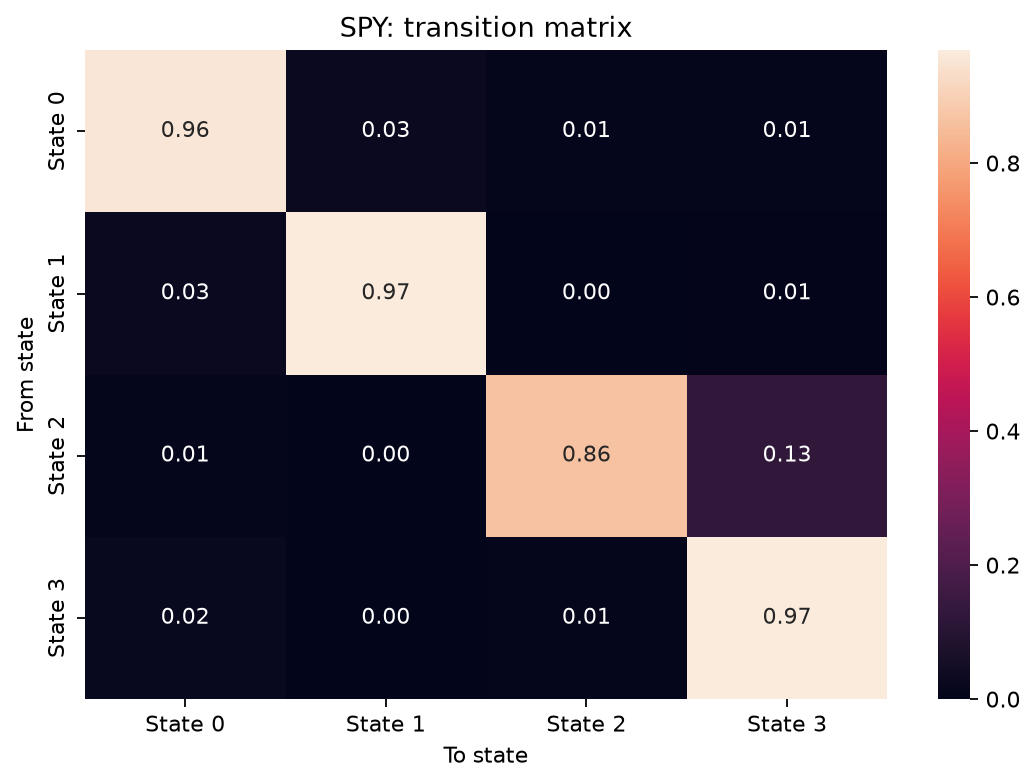

,state,self_transition_probability,hmm_implied_mean_duration_days,decoded_empirical_mean_duration_days,empirical_to_implied_duration_ratio
28,0,0.956,22.774,25.000,1.098
29,1,0.965,28.720,32.389,1.128
30,2,0.864,7.337,8.000,1.090
31,3,0.968,31.735,35.208,1.109


In [6]:
display(Image(filename=str(EXTENDED_RUN / "SPY" / "transition_matrix.png")))
duration = pd.read_csv(EXTENDED_RUN / "state_duration_diagnostics.csv")
display(duration[duration["asset"] == "SPY"][
    ["state", "self_transition_probability", "hmm_implied_mean_duration_days", "decoded_empirical_mean_duration_days", "empirical_to_implied_duration_ratio"]
].round(3))

<div dir="rtl">

ב-SPY משכי השהייה האמפיריים קרובים יחסית לממוצעים הנגזרים מ-\(1/(1-a_{ii})\). לכן לא נמצא mismatch ברור שמצדיק טענה שהנחת duration נכשלה. הרחבה ל-Hidden Semi-Markov Model יכולה עדיין לבדוק את כל התפלגות ה-duration ולא רק את הממוצע.

</div>

<div dir="rtl">

## 7. Posterior uncertainty — מידע מעבר ל-label

חושבה entropy מנורמלת:

\[
H_t=-\frac{\sum_k\gamma_t(k)\log\gamma_t(k)}{\log K}
\]

ערך נמוך מצביע על posterior חד; ערך גבוה מצביע על ambiguity בין states.

</div>

,מדד,ערך
0,Mean confidence,0.966
1,Mean entropy,0.067
2,Entropy on switch days,0.307
3,Entropy on non-switch days,0.054
4,Entropy near switch ±1,0.236
5,Corr entropy vs |return|,0.027
6,Corr entropy vs rolling vol,-0.076


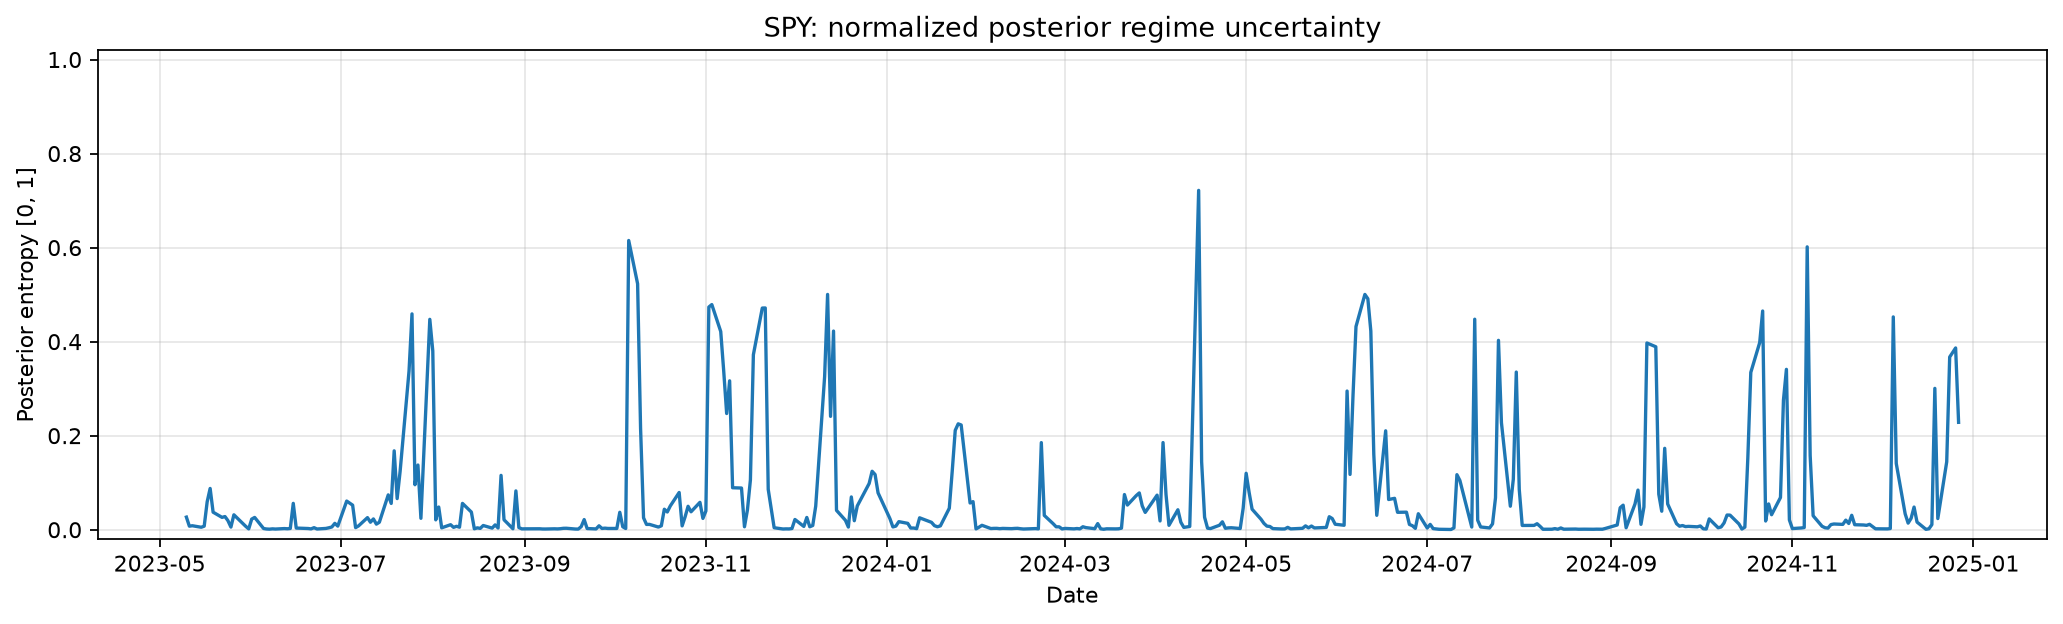

In [7]:
with (EXTENDED_RUN / "SPY" / "selected_model_summary.json").open(encoding="utf-8") as f:
    spy_model_summary = json.load(f)
unc = spy_model_summary["posterior_uncertainty"]
unc_table = pd.DataFrame({
    "מדד": ["Mean confidence", "Mean entropy", "Entropy on switch days", "Entropy on non-switch days", "Entropy near switch ±1", "Corr entropy vs |return|", "Corr entropy vs rolling vol"],
    "ערך": [unc["mean_confidence"], unc["mean_entropy"], unc["mean_entropy_on_switch_days"], unc["mean_entropy_on_non_switch_days"], unc["mean_entropy_near_switch_plus_minus_1"], unc["entropy_abs_return_correlation"], unc["entropy_rolling_volatility_correlation"]],
})
display(unc_table.round(3))
display(Image(filename=str(EXTENDED_RUN / "SPY" / "posterior_entropy_timeline.png")))

<div dir="rtl">

posterior confidence ממוצע ב-SPY הוא כ-96.6%, אבל entropy בימי switch עולה לכ-0.307 לעומת כ-0.054 בימים ללא switch. זהו diagnostic שימושי של ambiguity, אך חשוב לפרש אותו בזהירות: hard switch מוגדר משינוי ב-argmax של אותו posterior, ולכן צפוי במידה מסוימת שימים ליד הגבול יהיו גם בעלי entropy גבוהה יותר. המתאם של entropy עם absolute return או rolling volatility כמעט אפסי, ולכן היא אינה פשוט proxy לתנודתיות. הקשר ל-switch מוצג כאן כמדד פנימי של confidence ולא כ-validation חיצוני עצמאי.

</div>

<div dir="rtl">

## 8. External validation מול VIX

`VIX` לא שימש Feature ולא השתתף באימון. לכן הוא מאפשר בדיקת post-hoc חיצונית של פרשנות ה-states.

</div>

,spy_state,n_days,mean_vix,median_vix,p90_vix,mean_vix_log_change_%,share_vix_above_20_%,share_vix_above_30_%,mean_spy_abs_return_%,mean_spy_posterior_entropy
0,0,325,15.340,14.61,19.098,-0.039,6.154,0.000,0.560,0.057
1,1,41,12.959,12.75,13.930,0.454,0.000,0.000,0.385,0.111
2,3,46,18.551,17.28,23.940,-0.356,26.087,2.174,0.906,0.103


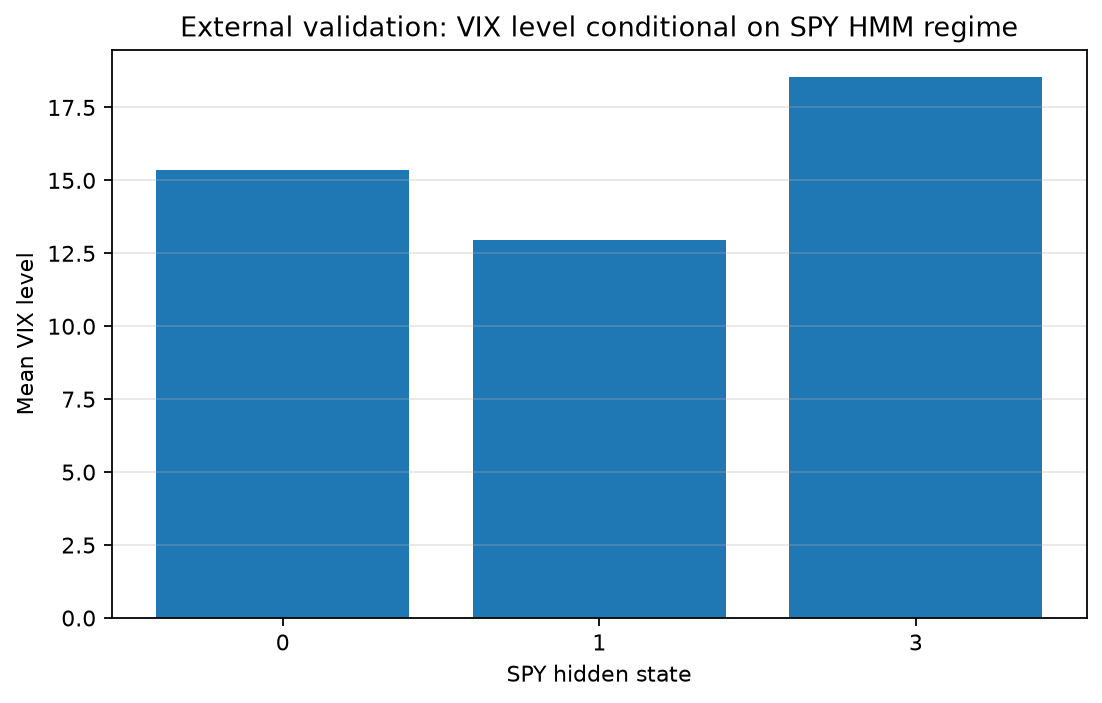

,n_overlapping_days,entropy_vix_level_correlation,entropy_abs_vix_change_correlation,low_entropy_quartile_mean_vix,high_entropy_quartile_mean_vix,low_entropy_quartile_mean_abs_vix_change_%,high_entropy_quartile_mean_abs_vix_change_%
0,412,-0.036,-0.01,14.812,14.986,3.793,4.489


In [8]:
vix = pd.read_csv(EXTENDED_RUN / "vix_by_spy_regime.csv")
display(vix.round(3))
display(Image(filename=str(EXTENDED_RUN / "vix_by_spy_regime.png")))
with (EXTENDED_RUN / "vix_external_validation.json").open(encoding="utf-8") as f:
    vix_validation = json.load(f)
display(pd.DataFrame([vix_validation]).round(3))

<div dir="rtl">

בחלון המבחן State 1 קשור ל-VIX ממוצע של כ-12.96, State 0 לכ-15.34 ו-State 3 לכ-18.55. ב-State 3 כ-26% מהימים היו מעל VIX=20. State 2 הנדיר לא הופיע בחפיפה ולכן אינו מאומת כאן. גם entropy עצמה כמעט אינה מתואמת עם VIX, ולכן אין לזהות בין uncertainty של ה-HMM לבין "פחד בשוק".

</div>

<div dir="rtl">

## 9. Cross-asset analysis: האם state של SPY הוא מצב שוק רחב יותר?

נבדקה התנהגות יתר הנכסים מותנית ב-state של SPY, תוך שימוש בתאריכים חופפים בלבד. המטרה היא לראות האם return, volatility והקורלציה עם SPY משתנים בין regimes.

</div>

,SPY state 0,SPY state 1,SPY state 3
asset,,,
BTC-USD,0.207,0.329,0.631
GLD,0.198,0.118,0.394
HYG,0.636,0.515,0.773
IWM,0.733,0.240,0.879
JPM,0.435,0.106,0.680
NVDA,0.575,0.548,0.769
QQQ,0.924,0.849,0.978
TLT,0.213,0.265,-0.044


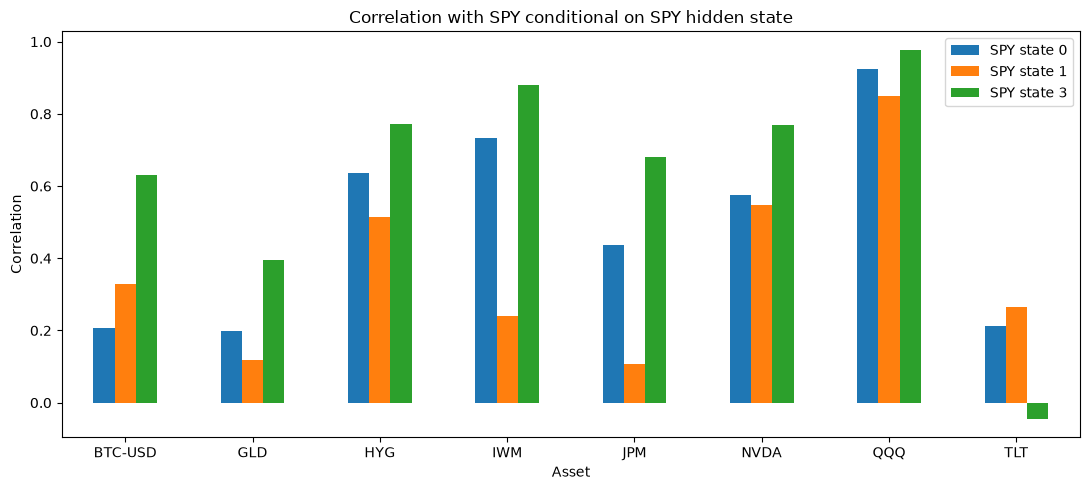

In [9]:
cross_asset = pd.read_csv(EXTENDED_RUN / "cross_asset_by_reference_state.csv")
focus_assets = ["QQQ", "IWM", "TLT", "GLD", "HYG", "BTC-USD", "JPM", "NVDA"]
cross_focus = cross_asset[cross_asset["asset"].isin(focus_assets)].copy()
corr_pivot = cross_focus.pivot(index="asset", columns="reference_state", values="correlation_with_reference")
corr_pivot.columns = [f"SPY state {c}" for c in corr_pivot.columns]
display(corr_pivot.round(3))
ax = corr_pivot.plot(kind="bar", figsize=(11, 5))
ax.set_title("Correlation with SPY conditional on SPY hidden state")
ax.set_ylabel("Correlation")
ax.set_xlabel("Asset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<div dir="rtl">

ב-State 3 הקורלציה עם SPY מגיעה לכ-0.98 ב-QQQ, 0.77 ב-HYG, 0.63 ב-BTC-USD, 0.68 ב-JPM ו-0.77 ב-NVDA. לעומת זאת TLT נמצא באותו state בקורלציה קרובה לאפס ואף מעט שלילית. זה תומך בכך שחלק מה-states מתלווים לשינוי במבנה התלות בין asset classes, אך זהו ניתוח תיאורי: בתקופת החפיפה היו 325 ימים ב-State 0, רק 41 ב-State 1 ו-46 ב-State 3, ו-State 2 לא הופיע. לכן אין כאן טענת מובהקות או סיבתיות.

</div>

<div dir="rtl">

## 10. חיזוי יום-קדימה: HMM מול Baselines

`DPA` הוא שיעור הימים שבהם סימן התשואה נחזה נכון. חשוב לזכור ש-Accuracy מעל 50% אינו בהכרח predictive edge: כאשר רוב ימי Test חיוביים, baseline שמנבא את הכיוון הדומיננטי יכול לקבל DPA גבוה יחסית בלי לזהות signal יומי אמיתי.

</div>

,model,mean_DPA_%
5,Naive - train mean,54.54
7,Logistic Regression,54.14
0,Discrete Markov Chain,53.90
8,Random Forest Classifier,53.27
2,Gaussian HMM - soft posterior,53.06
6,HistGradientBoostingClassifier,52.49
1,Gaussian HMM - hard state,52.06
4,Naive - persistence,50.45
3,Moving Average 5,50.27


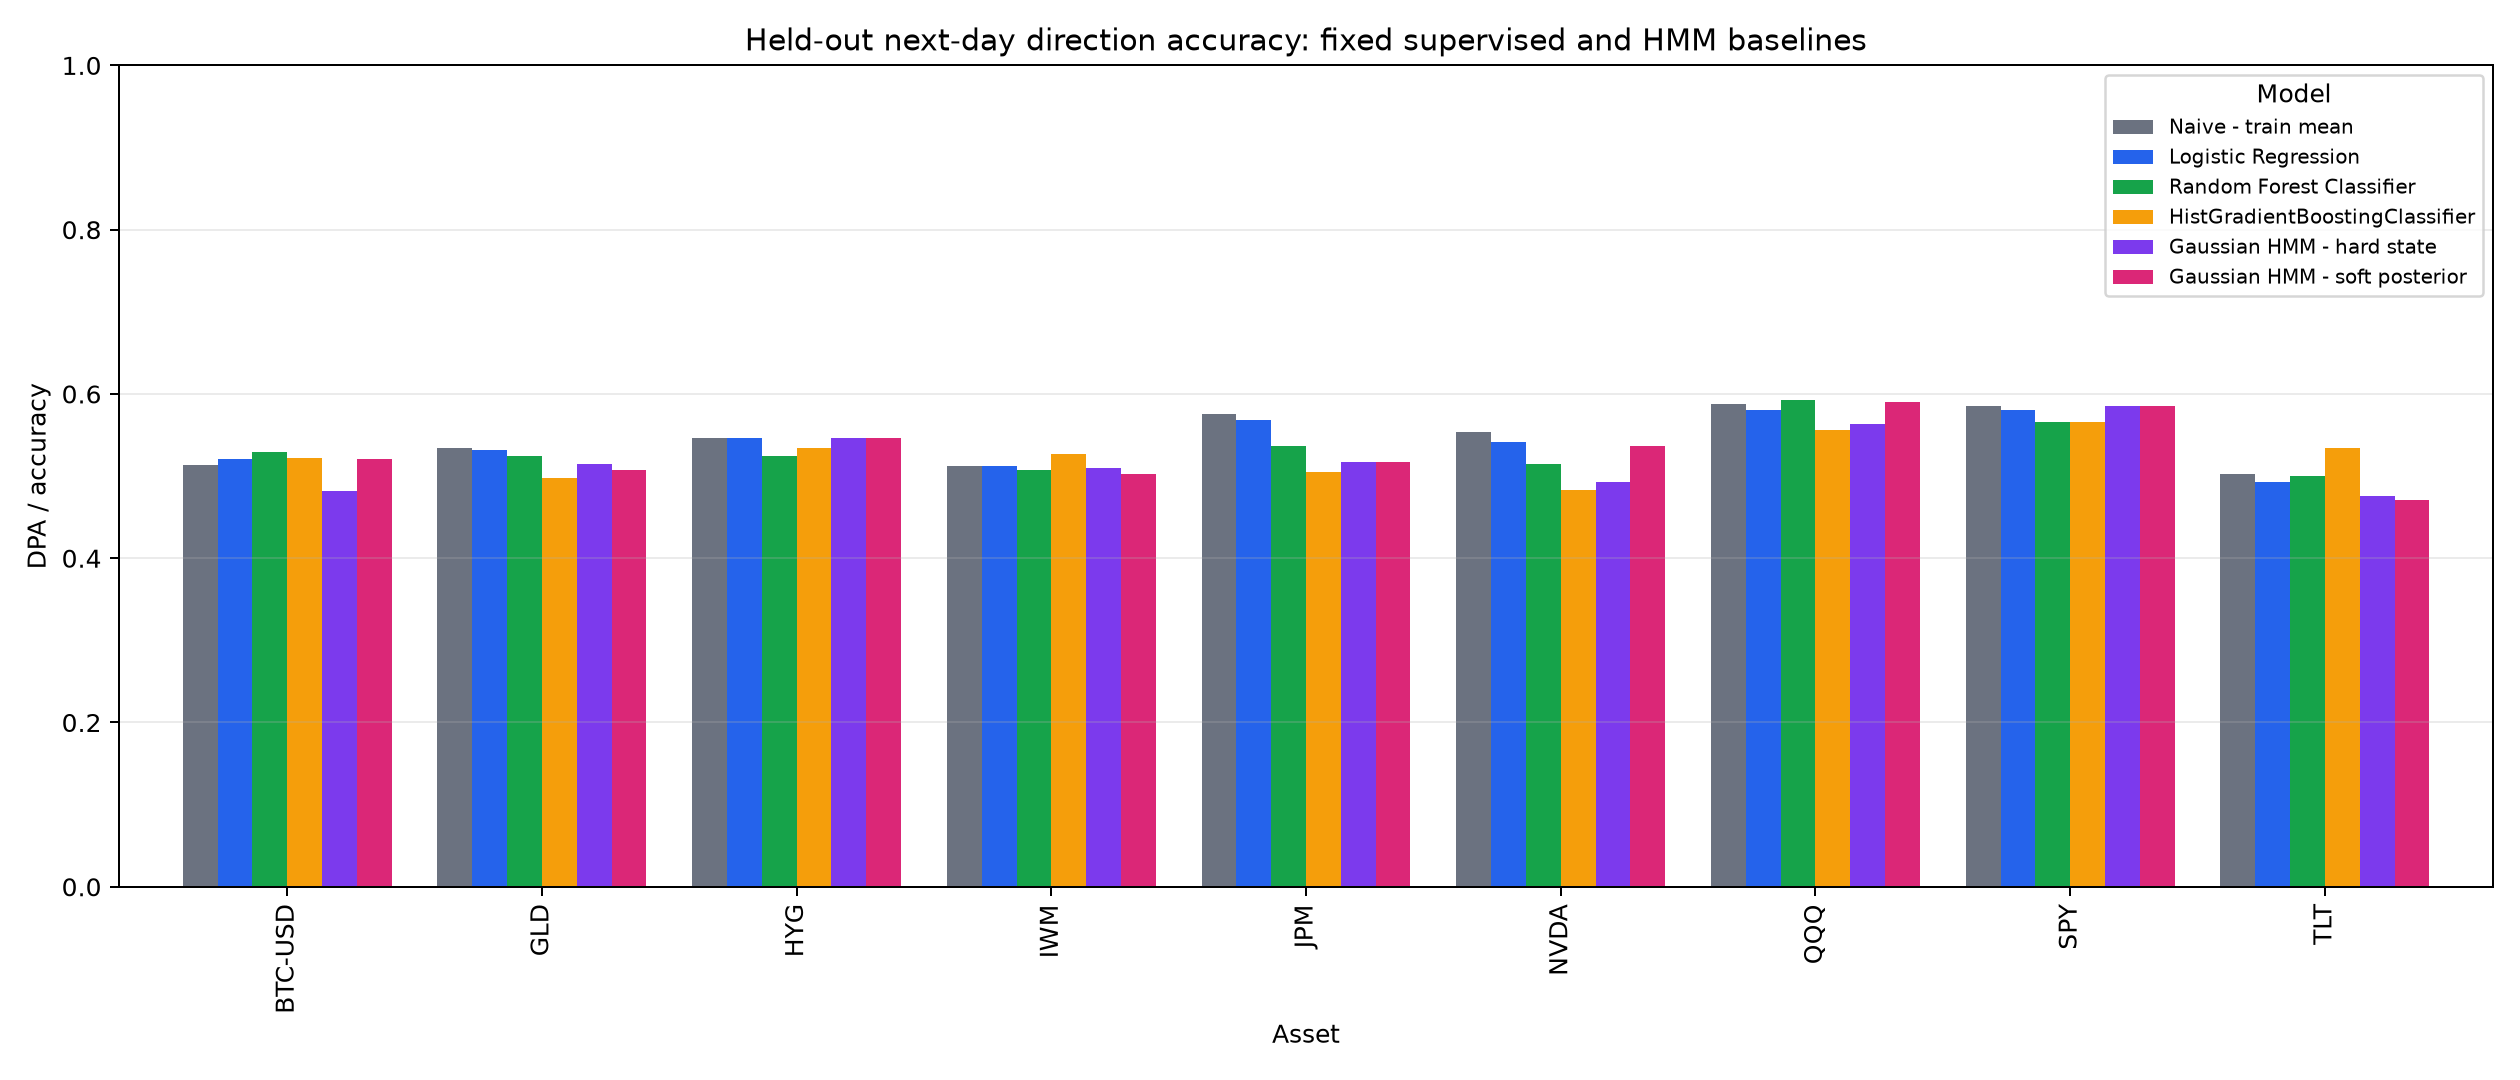

In [10]:
hmm_metrics = pd.read_csv(EXTENDED_RUN / "test_metrics_all_assets.csv")
mean_hmm = (
    hmm_metrics.groupby("model", as_index=False)["DPA_direction_accuracy"]
    .mean()
)
supervised_summary = (
    pd.read_csv(SUPERVISED_RUN / "supervised_summary.csv")
    .rename(columns={"mean_DPA_direction_accuracy": "DPA_direction_accuracy"})
    [["model", "DPA_direction_accuracy"]]
)
mean_comparison = pd.concat([mean_hmm, supervised_summary], ignore_index=True)

expected_models = {
    "Naive - train mean", "Naive - persistence", "Moving Average 5",
    "Discrete Markov Chain", "Gaussian HMM - hard state",
    "Gaussian HMM - soft posterior", "Logistic Regression",
    "Random Forest Classifier", "HistGradientBoostingClassifier",
}
assert expected_models.issubset(set(mean_comparison["model"]))

mean_comparison["mean_DPA_%"] = 100 * mean_comparison["DPA_direction_accuracy"]
display(
    mean_comparison[["model", "mean_DPA_%"]]
    .sort_values("mean_DPA_%", ascending=False)
    .round(2)
)
display(Image(filename=str(SUPERVISED_RUN / "dpa_comparison_all_assets.png")))

<div dir="rtl">

בממוצע בין תשעת הנכסים: Naive train-mean משיג כ-54.54% DPA, Logistic Regression כ-54.14%, Discrete Markov Chain כ-53.90%, Random Forest כ-53.27%, HMM soft-posterior כ-53.06%, HistGradientBoosting כ-52.49%, HMM hard-state כ-52.06%, Naive persistence כ-50.45% ו-Moving Average 5 כ-50.27%.

יש הצלחות מקומיות, למשל Random Forest ב-QQQ וב-BTC-USD ו-soft HMM ב-QQQ, אבל אין מודל שמנצח באופן עקבי. הצגת כל ה-Baselines חשובה במיוחד משום ש-Discrete Markov Chain הפשוט נמצא בממוצע מעל שני ה-HMM variants. מאחר שמודלי ה-Supervised אומנו על Train בלבד בעוד ה-HMM הסופי הותאם מחדש על Train+Validation, אין לפרש את הדירוג הממוצע כתחרות מובהקת ביניהם. בכל מקרה, אין בסיס לטענה שה-HMM מספק predictive edge יציב.

</div>

<div dir="rtl">

### שגיאת magnitude על SPY

DPA מתייחס רק לסימן. עבור המודלים שמחזירים תחזית מספרית לתשואה נשמרו גם MAE ו-RMSE על next-day log return ו-MAPE על מחיר הסגירה המשתמע. MAPE מוצג כמדד משלים בלבד, משום שמחיר מחר בדרך כלל קרוב למחיר היום ולכן הוא עלול להיראות טוב גם עבור Baseline פשוט.

</div>

In [11]:
spy_numeric = hmm_metrics.loc[
    hmm_metrics["asset"] == "SPY",
    ["model", "DPA_direction_accuracy", "MAE_return", "RMSE_return", "MAPE_price_%"],
].copy()
spy_numeric["DPA_%"] = 100 * spy_numeric.pop("DPA_direction_accuracy")
display(
    spy_numeric[["model", "DPA_%", "MAE_return", "RMSE_return", "MAPE_price_%"]]
    .round({"DPA_%": 2, "MAE_return": 5, "RMSE_return": 5, "MAPE_price_%": 3})
)

,model,DPA_%,MAE_return,RMSE_return,MAPE_price_%
0,Naive - train mean,58.50,0.00577,0.00766,0.577
1,Naive - persistence,53.16,0.00816,0.01043,0.816
2,Moving Average 5,53.16,0.00651,0.00846,0.651
3,Discrete Markov Chain,58.50,0.00579,0.00769,0.579
4,Gaussian HMM - hard state,58.50,0.00577,0.00767,0.577
5,Gaussian HMM - soft posterior,58.50,0.00577,0.00767,0.577


<div dir="rtl">

על SPY ה-hard וה-soft HMM כמעט זהים ל-Naive train-mean גם ב-MAE/RMSE/MAPE. כלומר גם כאשר עוברים מעבר לכיוון בלבד, אין כאן פער מעשי גדול לטובת ה-HMM. הדבר מחזק את הפרשנות שהערך המרכזי שלו בפרויקט הוא ייצוג מצב השוק ולא point forecast מדויק יותר.

</div>

<div dir="rtl">

## 11. Supervised ML Baselines

שלושת המודלים קיבלו בדיוק את אותם ארבעה Features ואותו split כרונולוגי. ה-hyperparameters נקבעו מראש ולא כוונו לפי Validation או Test, והמודלים אומנו על Train בלבד. לעומת זאת, ה-HMM הסופי עובר refit על Train+Validation לאחר model selection. לכן זו השוואת Baselines משלימה על אותו Test ולא תחרות שבה לכל המודלים ניתנה בדיוק אותה כמות נתוני אימון. בנוסף ל-DPA נמדדו Balanced Accuracy, ROC-AUC, Log Loss ו-Brier Score.

</div>

In [12]:
sup = pd.read_csv(SUPERVISED_RUN / "supervised_results_all_assets.csv")
summary = sup.groupby("model", as_index=False).agg(
    mean_DPA=("DPA_direction_accuracy", "mean"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    mean_ROC_AUC=("roc_auc", "mean"),
    mean_log_loss=("log_loss", "mean"),
    mean_brier=("brier_score", "mean"),
)
for c in ["mean_DPA", "mean_balanced_accuracy", "mean_ROC_AUC"]:
    summary[c] *= 100
display(summary.round(2))

,model,mean_DPA,mean_balanced_accuracy,mean_ROC_AUC,mean_log_loss,mean_brier
0,HistGradientBoostingClassifier,52.49,50.89,51.01,0.72,0.26
1,Logistic Regression,54.14,49.98,50.19,0.69,0.25
2,Random Forest Classifier,53.27,49.77,50.89,0.69,0.25


<div dir="rtl">

גם המודלים supervised נשארים ברוב המדדים סביב signal חלש; Balanced Accuracy ו-ROC-AUC קרובים בדרך כלל ל-50%. לכן הקושי ב-next-day forecasting אינו ייחודי ל-HMM. אם המטרה היחידה הייתה classification, אין יתרון ברור להשתמש ב-HMM. התרומה שלו היא states, transition dynamics, persistence ו-posterior uncertainty — מידע שה-classifiers אינם מייצרים באופן טבעי.

</div>

<div dir="rtl">

## 12. Walk-forward robustness על SPY

נוספו שלושה expanding windows. בכל fold מבוצעים Train → Validation → Test חדשים בסדר כרונולוגי, והמודל נבחר מחדש ללא שימוש ב-Test.

</div>

,fold,train_end,validation_end,test_start,test_end,selected_k,selected_seed,naive_train_mean_DPA,gaussian_hmm_hard_state_DPA,gaussian_hmm_soft_posterior_DPA
0,0,2020-01-29,2021-09-15,2021-09-17,2022-10-18,4,456,48.54,48.54,50.36
1,1,2021-03-03,2022-10-18,2022-10-20,2023-11-21,4,123,52.92,52.19,51.82
2,2,2022-04-04,2023-11-21,2023-11-24,2024-12-26,4,42,59.85,59.85,60.22


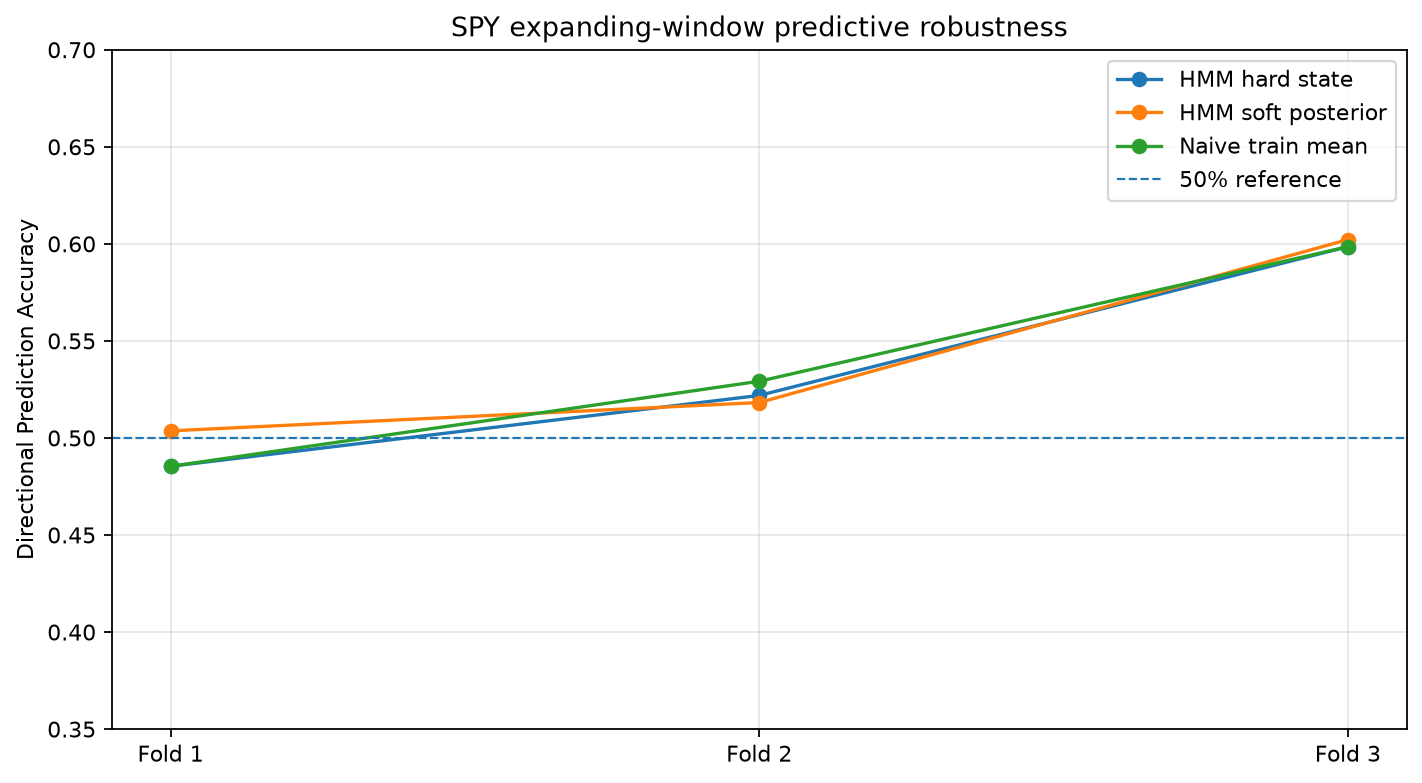

In [13]:
walk = pd.read_csv(EXTENDED_RUN / "walk_forward_results.csv")
walk_display = walk[["fold", "train_end", "validation_end", "test_start", "test_end", "selected_k", "selected_seed", "naive_train_mean_DPA", "gaussian_hmm_hard_state_DPA", "gaussian_hmm_soft_posterior_DPA"]].copy()
for c in ["naive_train_mean_DPA", "gaussian_hmm_hard_state_DPA", "gaussian_hmm_soft_posterior_DPA"]:
    walk_display[c] *= 100
display(walk_display.round(2))
display(Image(filename=str(EXTENDED_RUN / "walk_forward_dpa.png")))

<div dir="rtl">

בשלושת החלונות soft HMM משיג בקירוב 50.36%, 51.82% ו-60.22%, לעומת 48.54%, 52.92% ו-59.85% ל-Naive. הממוצע מעט גבוה יותר ל-soft HMM, אך הוא אינו מנצח בכל fold והפער קטן. לכן ייתכן שמידע על regime מסייע בתקופות מסוימות, אך אין ראיה ליתרון חיזוי יציב.

</div>

<div dir="rtl">

## 13. מסקנה מרכזית

הניסוי מפריד בין **forecasting** לבין **representation**:

1. HMM אינו מנצח באופן עקבי את Baselines או Supervised ML בחיזוי היום הבא.
2. ב-SPY מתקבלים states נבדלים מאוד ב-return, volatility, range, drawdown ו-duration.
3. מבנה K=4 של SPY יציב מאוד בין seeds.
4. posterior entropy עולה סביב state switches אך אינה פשוט proxy ל-volatility.
5. VIX שלא שימש באימון מפריד בין חלק מה-states.
6. הקורלציות וה-volatility של נכסים אחרים משתנות כתלות ב-SPY regime.

לכן בפרויקט זה Gaussian HMM שימושי יותר כ-**latent market-state estimator** מאשר כ-point-forecasting model ליום הבא.

</div>

<div dir="rtl">

## 14. Future Work: Regime-aware Reinforcement Learning

המשך טבעי הוא לעבור מהסקת מצב לקבלת החלטה סדרתית. Observation עתידי יכול לכלול את ארבעת ה-Features, posterior probabilities של HMM, posterior entropy והפוזיציה הנוכחית. Action יכול להיות `sell / hold / buy` או משקל רציף בתיק, וה-reward צריך להיות תשואה נטו לאחר transaction costs עם penalty ל-turnover/סיכון.

הניסוי הנקי ביותר יהיה ablation:

- RL עם Features בלבד;
- RL עם Features + HMM posterior;
- RL עם Features + posterior + entropy.

כך ניתן לבדוק האם מידע לטנטי על regime מוסיף ערך אינקרמנטלי למדיניות. לא בוצע כאן ניסוי RL, ולכן אין טענה שהכיוון הזה ישפר ביצועים; הוא דורש walk-forward, multiple seeds ועלויות עסקה מפורשות.

</div>

<div dir="rtl">

## 15. שחזור והרצה

המחברת מציגה את התוצאות מה-artifacts המאומתים ואינה דורשת retraining. כדי ליצור ריצות חדשות:

```bash
python run_extended_analysis.py
python analyze_extended_context.py --run-dir experiments_extended/<run_id>
python run_supervised_baselines.py
```

כל ריצה חדשה נשמרת בתיקייה timestamped חדשה כדי לא לדרוס את התוצאות שעליהן מבוסס הדוח.

</div>